Papers:

"Habitable Zones Around Main Sequence Stars"

"A New Definition of Exoplanet Habitability"

Trying to graph isochrones.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import pathlib
import scipy
from scipy import constants as const
from astropy import constants as astroconst
from scipy.integrate import quad

In [ ]:
mass01 = "/content/0001000M.track.eep"

In [ ]:
def load_mist(filepath):
  colnames = None
#snip data
  with open(filepath, 'r') as f:
    for line in f:
      if line.startswith('#') and 'star_age' in line:
        colnames = line[1:].split()
        break
  if colnames is None:
    raise ValueError("No column header line")
#read data
  df = pd.read_csv(
      filepath,
      comment='#',
      delim_whitespace=True,
      names = colnames
  )
  return df

In [ ]:
df_01 = load_mist(mass01)

/tmp/ipython-input-2598988139.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [ ]:
df_01.head()
df_01.columns
df_01[['star_age', 'log_L', 'log_Teff']].head()

,star_age,log_L,log_Teff
0,60088.350133,-0.797748,3.467689
1,63284.719116,-0.802299,3.467765
2,66651.058656,-0.807022,3.467844
3,70194.471666,-0.811940,3.467926
4,73922.530873,-0.816986,3.468009


In [ ]:
print(df_01.columns)

Index(['star_age', 'star_mass', 'star_mdot', 'he_core_mass', 'c_core_mass',
       'o_core_mass', 'log_L', 'log_L_div_Ledd', 'log_LH', 'log_LHe', 'log_LZ',
       'log_Teff', 'log_abs_Lgrav', 'log_R', 'log_g', 'log_surf_z',
       'surf_avg_omega', 'surf_avg_v_rot', 'surf_num_c12_div_num_o16',
       'v_wind_Km_per_s', 'surf_avg_omega_crit',
       'surf_avg_omega_div_omega_crit', 'surf_avg_v_crit',
       'surf_avg_v_div_v_crit', 'surf_avg_Lrad_div_Ledd', 'v_div_csound_surf',
       'surface_h1', 'surface_he3', 'surface_he4', 'surface_li7',
       'surface_be9', 'surface_b11', 'surface_c12', 'surface_c13',
       'surface_n14', 'surface_o16', 'surface_f19', 'surface_ne20',
       'surface_na23', 'surface_mg24', 'surface_si28', 'surface_s32',
       'surface_ca40', 'surface_ti48', 'surface_fe56', 'log_center_T',
       'log_center_Rho', 'center_degeneracy', 'center_omega', 'center_gamma',
       'mass_conv_core', 'center_h1', 'center_he4', 'center_c12', 'center_n14',
       'center_o16

In [ ]:
# Constants used in HBZ flux boundaries
seff = [0,0,0,0,0,0]
seffsun  = [1.776,1.107, 0.356, 0.320, 1.188, 0.99]
a = [2.136e-4, 1.332e-4, 6.171e-5, 5.547e-5, 1.433e-4, 1.209e-4]  # K^-1
b = [2.533e-8, 1.580e-8, 1.698e-9, 1.526e-9, 1.707e-8, 1.404e-8]  # K^-2
c = [-1.332e-11, -8.308e-12, -3.198e-12, -2.874e-12, -8.968e-12, -7.418e-12]  #K^-3
d = [-3.097e-15, -1.931e-15, -5.575e-16, -5.011e-16, -2.084e-15, -1.713e-15]  #K^-4

In [ ]:
# un logging
df_01['L'] = 10**(df_01['log_L'])
df_01['Teff'] = 10**(df_01['log_Teff'])

In [ ]:
print(df_01.head())
write_path = '/content/0001000M.track.eep'
df_01.to_csv(write_path, sep=',', index=False)
# HZ Coefficients from Kopparapu
hz_labels = [
    "Recent Venus",        # 0
    "Runaway Greenhouse",  # 1  <-- conservative inner
    "Maximum Greenhouse",  # 2  <-- conservative outer
    "Early Mars",          # 3  <-- optimistic outer
    "5ME Runaway",         # 4
    "0.1ME Runaway"        # 5
]

       star_age  star_mass     star_mdot  he_core_mass  c_core_mass  \
0  60088.350133        0.1 -9.983650e-14           0.0          0.0   
1  63284.719116        0.1 -9.824912e-14           0.0          0.0   
2  66651.058656        0.1 -9.662922e-14           0.0          0.0   
3  70194.471666        0.1 -9.497381e-14           0.0          0.0   
4  73922.530873        0.1 -9.328252e-14           0.0          0.0   

   o_core_mass     log_L  log_L_div_Ledd    log_LH  log_LHe  ...  \
0          0.0 -0.797748       -4.153912 -4.047864    -99.0  ...   
1          0.0 -0.802299       -4.162020 -4.008315    -99.0  ...   
2          0.0 -0.807022       -4.170390 -3.967334    -99.0  ...   
3          0.0 -0.811940       -4.179064 -3.924719    -99.0  ...   
4          0.0 -0.816986       -4.187916 -3.881073    -99.0  ...   

   acoustic_cutoff  max_conv_vel_div_csound  max_gradT_div_grada  \
0      1234.905677                 0.144564             1.118342   
1      1248.535049          

In [ ]:
# Getting T*
Tstar = df_01['Teff'].to_numpy() - 5780.0

In [ ]:
# Finding S effectives
for i, label in enumerate(hz_labels):
    seff_i = seffsun[i] + a[i]*Tstar + b[i]*Tstar**2 + c[i]*Tstar**3 + d[i]*Tstar**4
    seff_i = np.where(seff_i > 0, seff_i, np.nan)
    col_seff = f"S_eff_{label.replace(' ','_')}"
    col_dist = f"d_AU_{label.replace(' ','_')}"
    df_01[col_seff] = seff_i
    df_01[col_dist] = np.sqrt(df_01['L'].to_numpy() / seff_i )

/tmp/ipython-input-4063309481.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1e10)


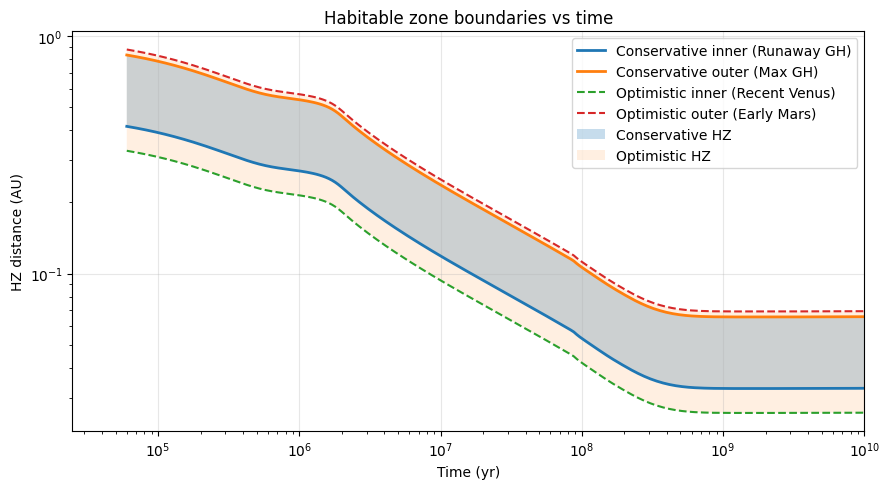

In [ ]:
# conservative and optimistic boundaries:
# conservative inner = Runaway Greenhouse (index 1)
# conservative outer = Maximum Greenhouse (index 2)
# optimistic inner = Recent Venus (index 0)
# optimistic outer = Early Mars (index 3)

t = df_01['star_age']

plt.figure(figsize=(9,5))

plt.semilogx(t, df_01['d_AU_Runaway_Greenhouse'], lw=2, label='Conservative inner (Runaway GH)')
plt.semilogx(t, df_01['d_AU_Maximum_Greenhouse'], lw=2, label='Conservative outer (Max GH)')
plt.semilogx(t, df_01['d_AU_Recent_Venus'], lw=1.5, ls='--', label='Optimistic inner (Recent Venus)')
plt.semilogx(t, df_01['d_AU_Early_Mars'], lw=1.5, ls='--', label='Optimistic outer (Early Mars)')


plt.fill_between(t, df_01['d_AU_Runaway_Greenhouse'], df_01['d_AU_Maximum_Greenhouse'],
                 alpha=0.25, label='Conservative HZ')
plt.fill_between(t, df_01['d_AU_Recent_Venus'], df_01['d_AU_Early_Mars'],
                 alpha=0.12, label='Optimistic HZ')

plt.xlabel('Time (yr)')
plt.xlim(0, 1e10)
plt.ylabel('HZ distance (AU)')
plt.yscale('log')
plt.title('Habitable zone boundaries vs time')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Constants
c = (float) (3e8)
h = const.h
kB = const.k
N_A = const.Avogadro
# P(I) constants from Hall et al. (2023)
alpha = 1.0e-5
beta = 1.0e-3
gamma = 2.0

In [ ]:
# R_rate values (respiration rates in micromol O2 mg^-1 hr^-1)
# From paper: Rrate ranges from 0.3 (optimistic) to 0.6 and 0.8 (pessimistic)
# These are actually P_max fractions, not absolute rates
r1 = 0.3/(beta + 2*(alpha*gamma)**0.5)
r2 = 0.6/(beta + 2*(alpha*gamma)**0.5)
r3 = 0.8/(beta + 2*(alpha*gamma)**0.5)
Pmax_values = [r1/3600, r2/3600, r3/3600] # changed from hr^-1 to s^-1

Pmax_labels = ['Excellent: R_rate= 0.3 Pmax', 'Optimistic: R_rate= 0.6 Pmax', 'Pessimistic: R_rate=0.8 Pmax']

# f_a values (atmospheric attenuation)
f_a_values = [1.0, 0.6, 0.2]
f_a_labels = ['No attenuation: f_a=1.0', 'Moderate: f_a=0.6', 'Earth-like: f_a=0.2']


In [ ]:
def calculate_N_dot_star(T_star, R_star):

    lambda_min = 400e-9  # 400 nm in METERS
    lambda_max = 700e-9  # 700 nm

    def integrand(lambda_m):
        # Planck function integrated over wavelength
        exponent = (h * c) / (lambda_m * kB * T_star)
        # Avoid overflow in exponential
        if exponent > 700:
            return 0
        try:
            planck = (2 * c) / (lambda_m**4) * (1 / (np.exp(exponent) - 1))
            return planck
        except Exception as e:
            print(f"Error in integrand: {e}")
            return 0 # Return 0 for any exceptions during planck calculation


    try:
        # we only need the integral value
        integral, _ = quad(integrand, lambda_min, lambda_max, limit=100)
        # Equation (9): N_dot = 4π^2R^2 \int B_lambda dlambda
        N_dot = 4 * np.pi**2 * R_star**2 * integral
        if np.isnan(N_dot) or not np.isfinite(N_dot): # Ensuring valid data for N star dot
             return np.nan
        return N_dot
    except Exception as e:
        print(f"Error in quad integration: {e} for T_star={T_star}. Returning NaN.")
        return np.nan # Return NaN if quad integration fails

In [ ]:
# Finding stellar radius
R_star = [] # meters
sigma = 5.670374419 * 10**(-8) # Stefan-Boltzmann Constant
for i in range(len(df_01['Teff'])):
  L_star = 3.828e26 * df_01['L'][i]
  R_star.append((L_star / (4 * np.pi * sigma * (df_01['Teff'][i]) ** 4))**0.5)

print(R_star)

[np.float64(1073551613.6316653), np.float64(1067566459.8825742), np.float64(1061392756.6043407), np.float64(1055002474.1325498), np.float64(1048488768.8486067), np.float64(1041768505.8821027), np.float64(1034902896.5291843), np.float64(1027856021.477101), np.float64(1020617825.2619327), np.float64(1013236853.7616268), np.float64(1005679688.0311518), np.float64(997943840.1864339), np.float64(990066775.5830573), np.float64(982055444.7634281), np.float64(973834694.6048542), np.float64(965512387.4047872), np.float64(957030465.258315), np.float64(948439830.5139657), np.float64(939688199.9465386), np.float64(930862157.3859946), np.float64(921889379.7375207), np.float64(912851518.0628483), np.float64(903686129.566583), np.float64(894440329.7910938), np.float64(885126936.1426089), np.float64(875755809.49482), np.float64(866346174.4717515), np.float64(856909364.9464625), np.float64(847459859.6897222), np.float64(838024823.9124568), np.float64(828602837.6171118), np.float64(819241715.2513492), n

In [ ]:
# Calculating N_dot_star for each timestep
N_dot_array = [] # s^-1
for i in range(len(df_01['Teff'])):
    T_star = df_01['Teff'].iloc[i]
    # Assuming solar-equivalent star because our data is a solar equiv star
    Rstar = R_star[i]

    N_dot = calculate_N_dot_star(T_star, Rstar)
    N_dot_array.append(N_dot)

In [ ]:
# After using quadratic equation to find when P(I) is 0, we define a min and a max to be the boundaries of P(I) being positive
a_min1 = []
a_max1 = []
a_min2 = []
a_max2 = []
a_min3 = []
a_max3 = []
a_min4 = []
a_max4 = []
a_min5 = []
a_max5 = []
a_min6 = []
a_max6 = []
a_min7 = []
a_max7 = []
a_min8 = []
a_max8 = []
a_min9 = []
a_max9 = []

# Filter out None and NaN values from N_dot_array and get corresponding isochrones data

for N_dot in N_dot_array:
  # Calculate the discriminant
  discriminant1 = (Pmax_values[0] * beta - 1)**2 - (4 * Pmax_values[0]**2 * alpha * gamma)
  discriminant2 = (Pmax_values[1] * beta - 1)**2 - (4 * Pmax_values[1]**2 * alpha * gamma)
  discriminant3 = (Pmax_values[2] * beta - 1)**2 - (4 * Pmax_values[2]**2 * alpha * gamma)

  # For f_a = 1.0, R_rate = r1
  if discriminant1 >= 0:
    sqrt_discriminant1 = (discriminant1)**(1/2)
    term1_1 = (4 * np.pi * f_a_values[0]) / N_dot
    term2_1 = ((1 - beta * Pmax_values[0]) - sqrt_discriminant1) / (2*Pmax_values[0])
    result_min1 = term1_1 * term2_1
    a_min1.append(result_min1**(1/2))

    term1_1_max = (4 * np.pi * f_a_values[0]) / N_dot
    term2_1_max = ((1 - beta * Pmax_values[0]) + sqrt_discriminant1) / (2*Pmax_values[0])
    result_max1 = term1_1_max * term2_1_max
    a_max1.append(result_max1**(1/2))

  else:
    a_min1.append(np.nan)
    a_max1.append(np.nan)

  # For f_a = 1.0, R_rate = r2
  if discriminant2 >= 0:
    sqrt_discriminant2 = (discriminant2)**(1/2)
    term1_2 = (4 * np.pi * f_a_values[0]) / N_dot
    term2_2 = ((1 - beta * R_rate_values[1]) - sqrt_discriminant2) / (2*R_rate_values[1])
    result_min2 = term1_2 * term2_2
    a_min2.append(result_min2**(1/2))

    term1_2_max = (4 * np.pi * f_a_values[0]) / N_dot
    term2_2_max = ((1 - beta * R_rate_values[1]) + sqrt_discriminant2) / (2*R_rate_values[1])
    result_max2 = term1_2_max * term2_2_max
    a_max2.append(result_max2**(1/2))
  else:
    a_min2.append(np.nan)
    a_max2.append(np.nan)


  # For f_a = 1.0, R_rate = r3
  if discriminant3 >= 0:
    sqrt_discriminant3 = (discriminant3)**(1/2)
    term1_3 = (4 * np.pi * f_a_values[0]) / N_dot
    term2_3 = ((1 - beta * R_rate_values[2]) - sqrt_discriminant3) / (2*R_rate_values[2])
    result_min3 = term1_3 * term2_3
    a_min3.append(result_min3**(1/2))

    term1_3_max = (4 * np.pi * f_a_values[0]) / N_dot
    term2_3_max = ((1 - beta * R_rate_values[2]) + sqrt_discriminant3) / (2*R_rate_values[2])
    result_max3 = term1_3_max * term2_3_max
    a_max3.append(result_max3**(1/2))
  else:
    a_min3.append(np.nan)
    a_max3.append(np.nan)


  # For f_a = 0.6, R_rate = r1
  if discriminant1 >= 0:
    sqrt_discriminant1 = (discriminant1)**(1/2)
    term1_4 = (4 * np.pi * f_a_values[1]) / N_dot
    term2_4 = ((1 - beta * R_rate_values[0]) - sqrt_discriminant1) / (2*R_rate_values[0])
    result_min4 = term1_4 * term2_4
    a_min4.append(result_min4**(1/2))

    term1_4_max = (4 * np.pi * f_a_values[1]) / N_dot
    term2_4_max = ((1 - beta * R_rate_values[0]) + sqrt_discriminant1) / (2*R_rate_values[0])
    result_max4 = term1_4_max * term2_4_max
    a_max4.append(result_max4**(1/2))
  else:
    a_min4.append(np.nan)
    a_max4.append(np.nan)


  # For f_a = 0.6, R_rate = r2
  if discriminant2 >= 0:
    sqrt_discriminant2 = (discriminant2)**(1/2)
    term1_5 = (4 * np.pi * f_a_values[1]) / N_dot
    term2_5 = ((1 - beta * R_rate_values[1]) - sqrt_discriminant2) / (2*R_rate_values[1])
    result_min5 = term1_5 * term2_5
    a_min5.append(result_min5**(1/2))

    term1_5_max = (4 * np.pi * f_a_values[1]) / N_dot
    term2_5_max = ((1 - beta * R_rate_values[1]) + sqrt_discriminant2) / (2*R_rate_values[1])
    result_max5 = term1_5_max * term2_5_max
    a_max5.append(result_max5**(1/2))
  else:
    a_min5.append(np.nan)
    a_max5.append(np.nan)


  # For f_a = 0.6, R_rate = r3
  if discriminant3 >= 0:
    sqrt_discriminant3 = (discriminant3)**(1/2)
    term1_6 = (4 * np.pi * f_a_values[1]) / N_dot
    term2_6 = ((1 - beta * R_rate_values[2]) - sqrt_discriminant3) / (2*R_rate_values[2])
    result_min6 = term1_6 * term2_6
    a_min6.append(result_min6**(1/2))

    term1_6_max = (4 * np.pi * f_a_values[1]) / N_dot
    term2_6_max = ((1 - beta * R_rate_values[2]) + sqrt_discriminant3) / (2*R_rate_values[2])
    result_max6 = term1_6_max * term2_6_max
    a_max6.append(result_max6**(1/2))
  else:
    a_min6.append(np.nan)
    a_max6.append(np.nan)


  # For f_a = 0.2, R_rate = r1
  if discriminant1 >= 0:
    sqrt_discriminant1 = (discriminant1)**(1/2)
    term1_7 = (4 * np.pi * f_a_values[2]) / N_dot
    term2_7 = ((1 - beta * R_rate_values[0]) - sqrt_discriminant1) / (2*R_rate_values[0])
    result_min7 = term1_7 * term2_7
    a_min7.append(result_min7**(1/2))

    term1_7_max = (4 * np.pi * f_a_values[2]) / N_dot
    term2_7_max = ((1 - beta * R_rate_values[0]) + sqrt_discriminant1) / (2*R_rate_values[0])
    result_max7 = term1_7_max * term2_7_max
    a_max7.append(result_max7**(1/2))
  else:
    a_min7.append(np.nan)
    a_max7.append(np.nan)


  # For f_a = 0.2, R_rate = r2
  if discriminant2 >= 0:
    sqrt_discriminant2 = (discriminant2)**(1/2)
    term1_8 = (4 * np.pi * f_a_values[2]) / N_dot
    term2_8 = ((1 - beta * R_rate_values[1]) - sqrt_discriminant2) / (2*R_rate_values[1])
    result_min8 = term1_8 * term2_8
    a_min8.append(result_min8**(1/2))

    term1_8_max = (4 * np.pi * f_a_values[2]) / N_dot
    term2_8_max = ((1 - beta * R_rate_values[1]) + sqrt_discriminant2) / (2*R_rate_values[1])
    result_max8 = term1_8_max * term2_8_max
    a_max8.append(result_max8**(1/2))
  else:
    a_min8.append(np.nan)
    a_max8.append(np.nan)


  # For f_a = 0.2, R_rate = r3
  if discriminant3 >= 0:
    sqrt_discriminant3 = (discriminant3)**(1/2)
    term1_9 = (4 * np.pi * f_a_values[2]) / N_dot
    term2_9 = ((1 - beta * R_rate_values[2]) - sqrt_discriminant3) / (2*R_rate_values[2])
    result_min9 = term1_9 * term2_9
    a_min9.append(result_min9**(1/2))

    term1_9_max = (4 * np.pi * f_a_values[2]) / N_dot
    term2_9_max = ((1 - beta * R_rate_values[2]) + sqrt_discriminant3) / (2*R_rate_values[2])
    result_max9 = term1_9_max * term2_9_max
    a_max9.append(result_max9**(1/2))
  else:
    a_min9.append(np.nan)
    a_max9.append(np.nan)


/tmp/ipython-input-2362470271.py:52: RuntimeWarning: invalid value encountered in scalar power
  a_min2.append(result_min2**(1/2))
/tmp/ipython-input-2362470271.py:69: RuntimeWarning: invalid value encountered in scalar power
  a_min3.append(result_min3**(1/2))
/tmp/ipython-input-2362470271.py:86: RuntimeWarning: invalid value encountered in scalar power
  a_min4.append(result_min4**(1/2))
/tmp/ipython-input-2362470271.py:103: RuntimeWarning: invalid value encountered in scalar power
  a_min5.append(result_min5**(1/2))
/tmp/ipython-input-2362470271.py:120: RuntimeWarning: invalid value encountered in scalar power
  a_min6.append(result_min6**(1/2))
/tmp/ipython-input-2362470271.py:137: RuntimeWarning: invalid value encountered in scalar power
  a_min7.append(result_min7**(1/2))
/tmp/ipython-input-2362470271.py:154: RuntimeWarning: invalid value encountered in scalar power
  a_min8.append(result_min8**(1/2))
/tmp/ipython-input-2362470271.py:171: RuntimeWarning: invalid value encountered

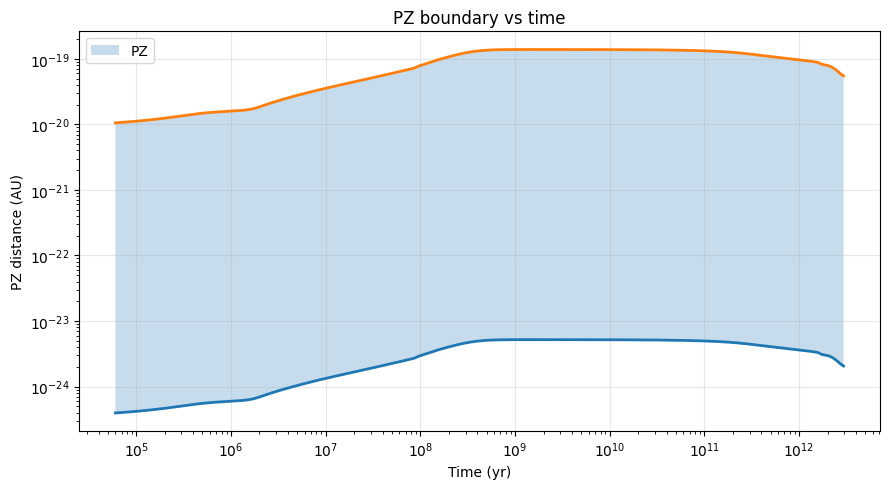

In [ ]:

plt.figure(figsize=(9,5))

plt.semilogx(t, a_min1, lw=2)
plt.semilogx(t, a_max1, lw=2)

plt.fill_between(t, a_min1, a_max1,
                 alpha=0.25, label='PZ')

plt.xlabel('Time (yr)')
plt.ylabel('PZ distance (AU)')
plt.yscale('log')
plt.title('PZ boundary vs time')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()